## Download Dataset

In [ ]:
from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

file_id = "1jh3vSp9z5kIbmtGUmPZeGi_DYTofETuB"
downloaded = drive.CreateFile({"id": file_id})
downloaded.GetContentFile("dataset.csv")

print("Download complete!")

Download complete!


## Installs and Imports

In [ ]:
!pip install contractions wordcloud --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.7 MB/s eta 0:00:00


In [ ]:
import time
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import contractions
import nltk
import torch
import torch.nn as nn
from collections import Counter
from wordcloud import WordCloud
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from torch.utils.data import Dataset, DataLoader

nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

## Section 1: Data Understanding, Preprocessing, Tokenization and Padding

### Load and Explore the Dataset

In [ ]:
df = pd.read_csv("dataset.csv")
df.head()

,headline,is_sarcastic
0,thirtysomething scientists unveil doomsday clo...,1
1,dem rep. totally nails why congress is falling...,0
2,eat your veggies: 9 deliciously different recipes,0
3,inclement weather prevents liar from getting t...,1
4,mother comes pretty close to using word 'strea...,1


In [ ]:
df.shape

(28619, 2)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28619 entries, 0 to 28618
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   headline      28619 non-null  object
 1   is_sarcastic  28619 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 447.3+ KB


In [ ]:
df = df[["is_sarcastic", "headline"]].reset_index(drop=True)
df["is_sarcastic"].value_counts()

,count
is_sarcastic,
0,14985
1,13634


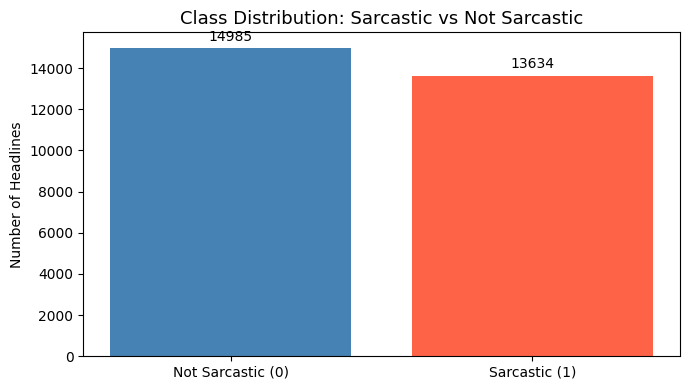

In [ ]:
# Class distribution bar chart
counts = df["is_sarcastic"].value_counts()
labels = ["Not Sarcastic (0)", "Sarcastic (1)"]
values = [counts[0], counts[1]]

plt.figure(figsize=(7, 4))
bars = plt.bar(labels, values, color=["steelblue", "tomato"])
plt.bar_label(bars, padding=3)
plt.title("Class Distribution: Sarcastic vs Not Sarcastic", fontsize=13)
plt.ylabel("Number of Headlines")
plt.tight_layout()
plt.show()

### Text Cleaning and Preprocessing

In [ ]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def clean_text(text):
    text = text.lower()
    text = contractions.fix(text)  # expand contractions: don't -> do not
    text = re.sub(r"http\S+", "", text)  # remove URLs
    text = re.sub(r"@\w+", "", text)  # remove mentions
    text = re.sub(r"#\w+", "", text)  # remove hashtags
    text = re.sub(r"\d+", "", text)  # remove numbers
    text = re.sub(r"[^a-z\s]", "", text)  # remove special characters
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words]
    return " ".join(tokens)


df["cleaned"] = df["headline"].apply(clean_text)

print("Original 1 :", df["headline"][0])
print("Cleaned 1 :", df["cleaned"][0])
print()
print()
print("Original 2 :", df["headline"][1])
print("Cleaned 2 :", df["cleaned"][1])

Original 1 : thirtysomething scientists unveil doomsday clock of hair loss
Cleaned 1 : thirtysomething scientist unveil doomsday clock hair loss


Original 2 : dem rep. totally nails why congress is falling short on gender, racial equality
Cleaned 2 : dem rep totally nail congress falling short gender racial equality


### Visualize Cleaned Data

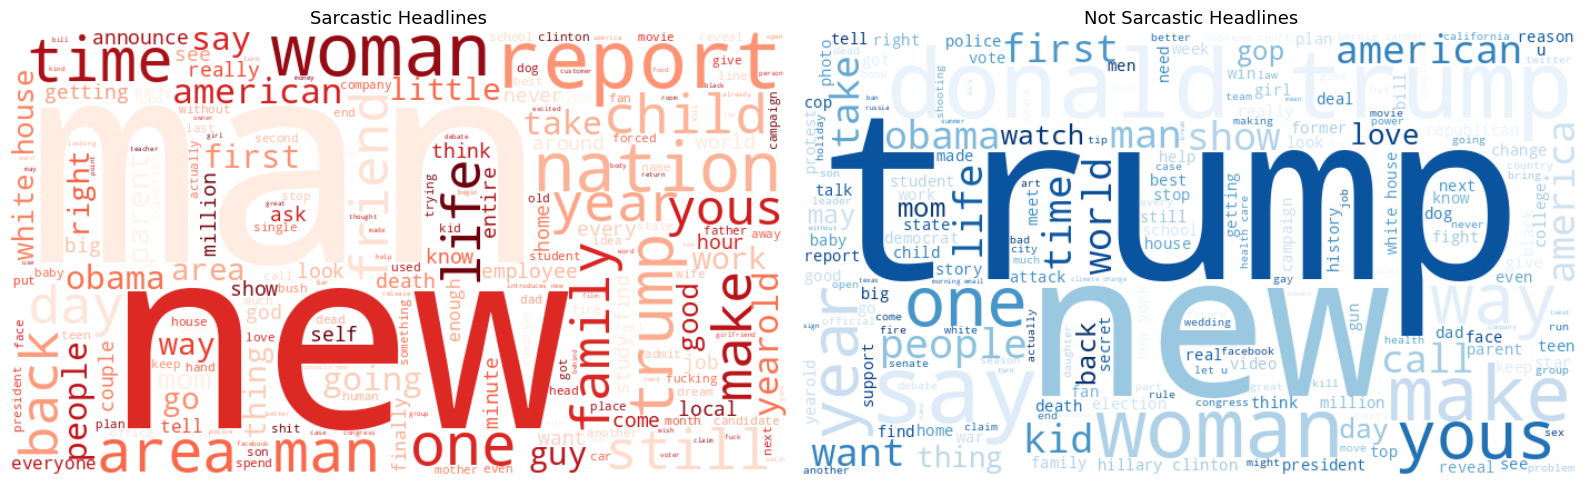

In [ ]:
# Word cloud
sarc_text = " ".join(df[df["is_sarcastic"] == 1]["cleaned"])
not_sarc_text = " ".join(df[df["is_sarcastic"] == 0]["cleaned"])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

wc_sarc = WordCloud(
    width=700, height=400, background_color="white", colormap="Reds"
).generate(sarc_text)
axes[0].imshow(wc_sarc, interpolation="bilinear")
axes[0].axis("off")
axes[0].set_title("Sarcastic Headlines", fontsize=13)

wc_not = WordCloud(
    width=700, height=400, background_color="white", colormap="Blues"
).generate(not_sarc_text)
axes[1].imshow(wc_not, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title("Not Sarcastic Headlines", fontsize=13)

plt.tight_layout()
plt.show()

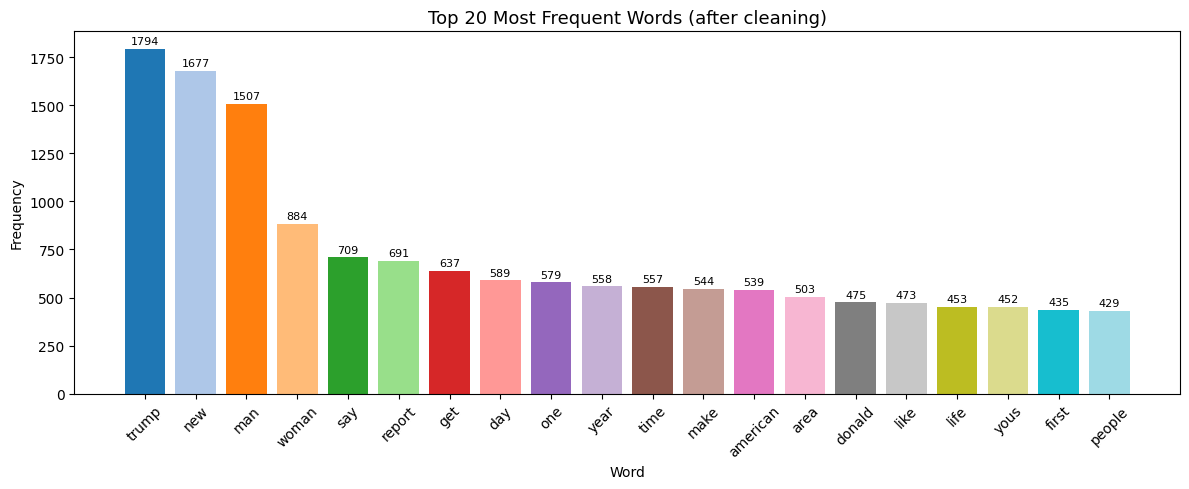

In [ ]:
# Top 20 most frequent words overall
all_words = " ".join(df["cleaned"]).split()
word_freq = Counter(all_words).most_common(20)
words, freqs = zip(*word_freq)

plt.figure(figsize=(12, 5))
bars = plt.bar(words, freqs, color=plt.cm.tab20.colors[:20])
plt.bar_label(bars, padding=2, fontsize=8)
plt.title("Top 20 Most Frequent Words (after cleaning)", fontsize=13)
plt.xlabel("Word")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Train/Test Split, Tokenization and Sequence Padding

In [ ]:
X = df["cleaned"].values
y = df["is_sarcastic"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", len(X_train))
print("Test size :", len(X_test))

Train size: 22895
Test size : 5724


In [ ]:
# Build vocabulary from training data only so that no leakage hapens
vocab = {"<PAD>": 0, "<UNK>": 1}

for sentence in X_train:
    for token in sentence.split():
        if token not in vocab:
            vocab[token] = len(vocab)

vocab_size = len(vocab)
vocab_size

22525

95th percentile sequence length: 11


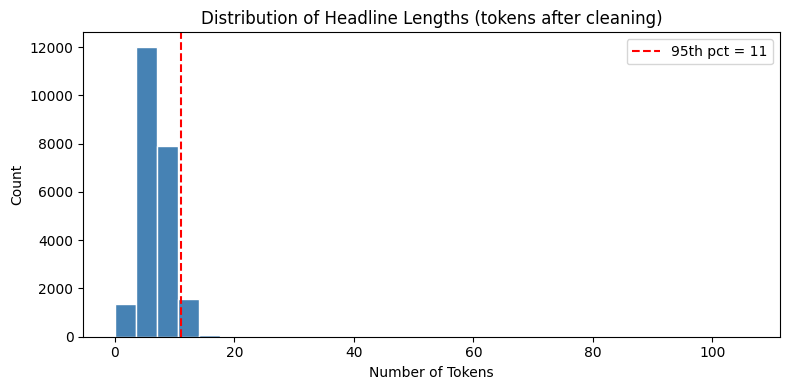

In [ ]:
# Percentile-based max length to avoid padding to outlier lengths
lengths = [len(s.split()) for s in X_train]
max_len = int(np.percentile(lengths, 95))
print(f"95th percentile sequence length: {max_len}")

plt.figure(figsize=(8, 4))
plt.hist(lengths, bins=30, color="steelblue", edgecolor="white")
plt.axvline(max_len, color="red", linestyle="--", label=f"95th pct = {max_len}")
plt.title("Distribution of Headline Lengths (tokens after cleaning)")
plt.xlabel("Number of Tokens")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

**Why did I do prepadding and not postpadding?**

Ans : Since we're using an RNN/LSTM that reads the sequence left to right and uses the final hidden state for classification, pre-padding puts the actual words right before that final step so the model's last hidden state captures real content rather than a string of zeros it just walked through after the meaningful tokens ended.

In [ ]:
def text_to_indices(sentence, vocab, max_len):
    tokens = sentence.split()[:max_len]
    indices = [vocab.get(t, vocab["<UNK>"]) for t in tokens]
    # Pre-padding with 0s
    padded = [0] * (max_len - len(indices)) + indices
    return padded


X_train_idx = np.array([text_to_indices(s, vocab, max_len) for s in X_train])
X_test_idx = np.array([text_to_indices(s, vocab, max_len) for s in X_test])

print("X_train_idx shape:", X_train_idx.shape)
print("X_test_idx shape :", X_test_idx.shape)

X_train_idx shape: (22895, 11)
X_test_idx shape : (5724, 11)


In [ ]:
class HeadlineDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


train_dataset = HeadlineDataset(X_train_idx, y_train)
test_dataset = HeadlineDataset(X_test_idx, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("No. of Train batches:", len(train_loader))
print("No. of Test batches:", len(test_loader))

No. of Train batches: 358
No. of Test batches: 90


## Section 2: Model Building

### Training Utilities

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    # Set to training mode (enables dropout/batch norm)
    model.train()
    running_loss, correct = 0.0, 0

    for X_batch, y_batch in loader:
        # Send data to device
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        # Clear old gradients
        optimizer.zero_grad()

        # Forward pass (flatten to match target shape)
        out = model(X_batch).squeeze(1)

        # Calculate loss
        loss = criterion(out, y_batch)

        # Backward pass
        loss.backward()

        # Update weights
        optimizer.step()

        # Track total loss
        running_loss += loss.item() * X_batch.size(0)

        # Convert logits to binary predictions
        preds = (torch.sigmoid(out) >= 0.5).long()

        # Count correct predictions
        correct += (preds == y_batch.long()).sum().item()

    return running_loss / len(loader.dataset), correct / len(loader.dataset)

In [ ]:
def evaluate(model, loader, criterion, device):
    # Set to evaluation mode (freezes dropout/batch norm)
    model.eval()
    running_loss, correct = 0.0, 0

    # Disable gradient calculation to save memory
    with torch.no_grad():
        for X_batch, y_batch in loader:
            # Send data to device
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            # Forward pass
            out = model(X_batch).squeeze(1)

            # Calculate loss
            loss = criterion(out, y_batch)

            # Track total loss
            running_loss += loss.item() * X_batch.size(0)

            # Convert logits to binary predictions
            preds = (torch.sigmoid(out) >= 0.5).long()

            # Count correct predictions
            correct += (preds == y_batch.long()).sum().item()

    return running_loss / len(loader.dataset), correct / len(loader.dataset)

In [ ]:
def train_model(
    model, train_loader, test_loader, criterion, optimizer, epochs, device, patience=5
):
    # Initialize dictionary to store results
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    start = time.time()
    best_val_loss = float("inf")
    best_state = None
    bad_epochs = 0

    for epoch in range(1, epochs + 1):
        # Run training phase
        tl, ta = train_one_epoch(model, train_loader, criterion, optimizer, device)

        # Run validation phase
        vl, va = evaluate(model, test_loader, criterion, device)

        # Store results for plotting
        history["train_loss"].append(tl)
        history["val_loss"].append(vl)
        history["train_acc"].append(ta)
        history["val_acc"].append(va)

        print(
            f"Epoch {epoch:02d}/{epochs} train_loss: {tl:.4f} train_acc: {ta:.4f} val_loss: {vl:.4f} val_acc: {va:.4f}"
        )

        # Check if validation loss improved
        if vl < best_val_loss:
            best_val_loss = vl
            # Save a copy of the best model weights
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            # Increment counter for early stopping
            bad_epochs += 1

        # Stop training if no improvement for 'patience' epochs
        if bad_epochs >= patience:
            print(
                f"Early stopping at epoch {epoch} (no improvement for {patience} epochs)"
            )
            break

    # Calculate total duration
    elapsed = time.time() - start
    print(f"\nTotal training time: {elapsed:.1f}s")

    # Restore the best performing weights
    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"Loaded best model with val_loss: {best_val_loss:.4f}")

    return history, elapsed

In [ ]:
def plot_history(history, title="Training History"):
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(epochs, history["train_loss"], label="Train Loss")
    axes[0].plot(epochs, history["val_loss"], label="Val Loss")
    axes[0].set_title(f"{title} — Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(epochs, history["train_acc"], label="Train Acc")
    axes[1].plot(epochs, history["val_acc"], label="Val Acc")
    axes[1].set_title(f"{title} — Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

In [ ]:
def plot_confusion_matrix(labels, preds, title="Confusion Matrix"):
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Not Sarcastic", "Sarcastic"],
        yticklabels=["Not Sarcastic", "Sarcastic"],
    )
    plt.title(title, fontsize=13)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

In [ ]:
def get_all_preds(model, loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            out = model(X_batch).squeeze(1)
            preds = (torch.sigmoid(out) >= 0.5).long().cpu().tolist()
            all_preds.extend(preds)
            all_labels.extend(y_batch.long().tolist())
    return all_labels, all_preds

### Model 1: Simple RNN with Trainable Embedding

In [ ]:
class SimpleRNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        embedded = self.embedding(x)  # (batch, seq_len, embed_dim)
        _, hidden = self.rnn(embedded)  # hidden: (1, batch, hidden_dim)
        hidden = self.dropout(hidden.squeeze(0))  # (batch, hidden_dim)
        out = self.fc(hidden)  # (batch, 1)
        return out


rnn_model = SimpleRNNClassifier(
    vocab_size=vocab_size, embed_dim=100, hidden_dim=128
).to(device)
print(rnn_model)
print(f"Total parameters: {sum(p.numel() for p in rnn_model.parameters()):,}")

SimpleRNNClassifier(
  (embedding): Embedding(22525, 100, padding_idx=0)
  (rnn): RNN(100, 128, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)
Total parameters: 2,282,069


**Model 1 Training**

In [ ]:
criterion = nn.BCEWithLogitsLoss()
rnn_optimizer = torch.optim.Adam(rnn_model.parameters(), lr=1e-3)

rnn_history, rnn_time = train_model(
    rnn_model,
    train_loader,
    test_loader,
    criterion,
    rnn_optimizer,
    epochs=20,
    device=device,
    patience=5,
)

Epoch 01/20 train_loss: 0.6559 train_acc: 0.6032 val_loss: 0.6368 val_acc: 0.6438
Epoch 02/20 train_loss: 0.5414 train_acc: 0.7310 val_loss: 0.5816 val_acc: 0.6929
Epoch 03/20 train_loss: 0.4357 train_acc: 0.8051 val_loss: 0.5918 val_acc: 0.7348
Epoch 04/20 train_loss: 0.3443 train_acc: 0.8562 val_loss: 0.6229 val_acc: 0.7416
Epoch 05/20 train_loss: 0.2738 train_acc: 0.8908 val_loss: 0.6604 val_acc: 0.7409
Epoch 06/20 train_loss: 0.2132 train_acc: 0.9204 val_loss: 0.6826 val_acc: 0.7575
Epoch 07/20 train_loss: 0.1561 train_acc: 0.9445 val_loss: 0.7881 val_acc: 0.7516
Early stopping at epoch 7 (no improvement for 5 epochs)

Total training time: 62.9s
Loaded best model with val_loss: 0.5816


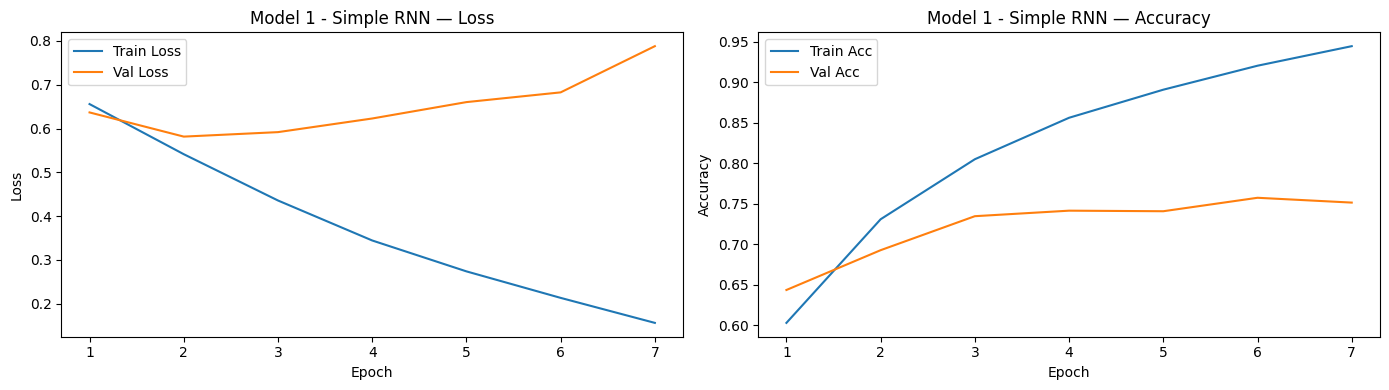

In [ ]:
plot_history(rnn_history, title="Model 1 - Simple RNN")

**Model 1 Evaluation**

Model 1 - Simple RNN - Test Accuracy: 0.6929

               precision    recall  f1-score   support

Not Sarcastic       0.69      0.74      0.72      2997
    Sarcastic       0.69      0.64      0.67      2727

     accuracy                           0.69      5724
    macro avg       0.69      0.69      0.69      5724
 weighted avg       0.69      0.69      0.69      5724



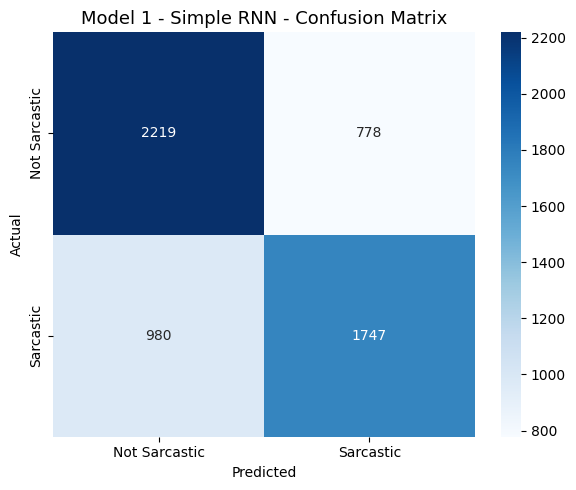

In [ ]:
rnn_labels, rnn_preds = get_all_preds(rnn_model, test_loader, device)
rnn_acc = accuracy_score(rnn_labels, rnn_preds)

print(f"Model 1 - Simple RNN - Test Accuracy: {rnn_acc:.4f}")
print()
print(
    classification_report(
        rnn_labels, rnn_preds, target_names=["Not Sarcastic", "Sarcastic"]
    )
)
plot_confusion_matrix(
    rnn_labels, rnn_preds, title="Model 1 - Simple RNN - Confusion Matrix"
)

### Model 2: LSTM with Trainable Embedding

In [ ]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim, num_layers=num_layers, batch_first=True, dropout=0.3
        )
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))  # dropout on embeddings
        _, (hidden, _) = self.lstm(embedded)  # hidden: (num_layers, batch, hidden_dim)
        hidden = self.dropout(hidden[-1])  # take last layer's hidden state
        out = self.fc(hidden)
        return out


lstm_model = LSTMClassifier(
    vocab_size=vocab_size, embed_dim=100, hidden_dim=128, num_layers=2
).to(device)
print(lstm_model)
print(f"Total parameters: {sum(p.numel() for p in lstm_model.parameters()):,}")

LSTMClassifier(
  (embedding): Embedding(22525, 100, padding_idx=0)
  (lstm): LSTM(100, 128, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)
Total parameters: 2,502,485


**Model 2 Training**

In [ ]:
lstm_optimizer = torch.optim.Adam(lstm_model.parameters(), lr=1e-3)

lstm_history, lstm_time = train_model(
    lstm_model,
    train_loader,
    test_loader,
    criterion,
    lstm_optimizer,
    epochs=20,
    device=device,
    patience=5,
)

Epoch 01/20 train_loss: 0.6247 train_acc: 0.6408 val_loss: 0.5902 val_acc: 0.6868
Epoch 02/20 train_loss: 0.5233 train_acc: 0.7383 val_loss: 0.6013 val_acc: 0.7180
Epoch 03/20 train_loss: 0.4515 train_acc: 0.7885 val_loss: 0.5367 val_acc: 0.7566
Epoch 04/20 train_loss: 0.3923 train_acc: 0.8243 val_loss: 0.5064 val_acc: 0.7689
Epoch 05/20 train_loss: 0.3516 train_acc: 0.8441 val_loss: 0.5410 val_acc: 0.7753
Epoch 06/20 train_loss: 0.3089 train_acc: 0.8657 val_loss: 0.5248 val_acc: 0.7853
Epoch 07/20 train_loss: 0.2791 train_acc: 0.8828 val_loss: 0.5702 val_acc: 0.7738
Epoch 08/20 train_loss: 0.2466 train_acc: 0.8986 val_loss: 0.5564 val_acc: 0.7895
Epoch 09/20 train_loss: 0.2189 train_acc: 0.9105 val_loss: 0.6150 val_acc: 0.7802
Early stopping at epoch 9 (no improvement for 5 epochs)

Total training time: 250.2s
Loaded best model with val_loss: 0.5064


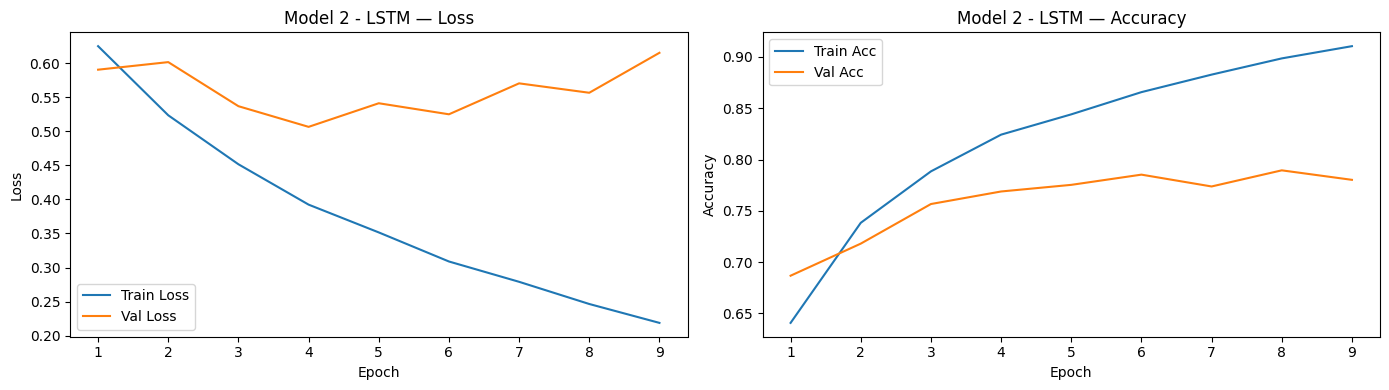

In [ ]:
plot_history(lstm_history, title="Model 2 - LSTM")

**Model 2 Evaluation**

Model 2 - LSTM - Test Accuracy: 0.7689

               precision    recall  f1-score   support

Not Sarcastic       0.75      0.83      0.79      2997
    Sarcastic       0.79      0.70      0.74      2727

     accuracy                           0.77      5724
    macro avg       0.77      0.77      0.77      5724
 weighted avg       0.77      0.77      0.77      5724



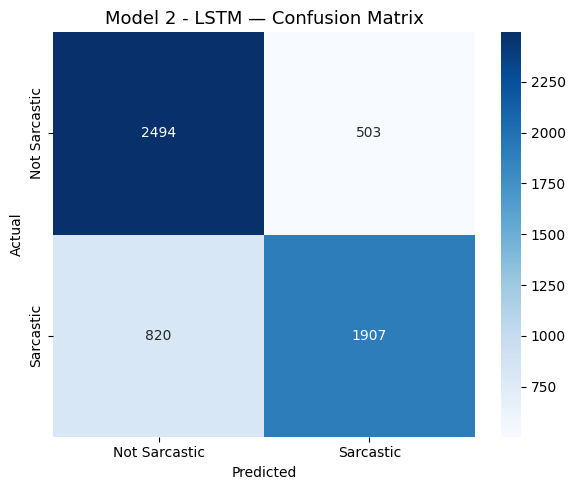

In [ ]:
lstm_labels, lstm_preds = get_all_preds(lstm_model, test_loader, device)
lstm_acc = accuracy_score(lstm_labels, lstm_preds)

print(f"Model 2 - LSTM - Test Accuracy: {lstm_acc:.4f}")
print()
print(
    classification_report(
        lstm_labels, lstm_preds, target_names=["Not Sarcastic", "Sarcastic"]
    )
)
plot_confusion_matrix(
    lstm_labels, lstm_preds, title="Model 2 - LSTM — Confusion Matrix"
)

### Model 3: LSTM with Pretrained Word2Vec Embeddings

In [ ]:
# 1. Uninstall the conflicting versions first
!pip uninstall -y numpy scipy gensim

# 2. Reinstall compatible versions together to resolve dependencies correctly
# Gensim 4.4.0 generally works best with NumPy < 2.0.0
!pip install "numpy<2.0.0" scipy --quiet
!pip install gensim --quiet

# 3. CRITICAL: Restart your runtime now if in Colab/Kaggle
# Then run this to verify:
import gensim

print(f"Gensim version: {gensim.__version__}")

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: scipy 1.16.3
Uninstalling scipy-1.16.3:
  Successfully uninstalled scipy-1.16.3
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 14.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy

In [ ]:
import gensim.downloader as api

# Load Word2Vec 300-dim pretrained embeddings (Google News)
w2v_model = api.load("word2vec-google-news-300")
embed_dim_w2v = 300

print("Word2Vec model loaded. Vocab size:", len(w2v_model))

[==================================================] 100.0% 1662.8/1662.8MB downloaded
Word2Vec model loaded. Vocab size: 3000000


In [ ]:
# Build embedding matrix: rows = word indices, cols = Word2Vec vector
embedding_matrix = np.zeros((vocab_size, embed_dim_w2v))

found = 0
for word, idx in vocab.items():
    if word in w2v_model:
        embedding_matrix[idx] = w2v_model[word]
        found += 1

# Explicitly zero out PAD and UNK so they contribute nothing to representation
embedding_matrix[vocab["<PAD>"]] = np.zeros(embed_dim_w2v)
embedding_matrix[vocab["<UNK>"]] = np.zeros(embed_dim_w2v)

print(
    f"Words found in Word2Vec: {found} / {vocab_size} ({100 * found / vocab_size:.1f}%)"
)

Words found in Word2Vec: 17920 / 22525 (79.6%)


In [ ]:
class LSTMWord2VecClassifier(nn.Module):
    def __init__(
        self, vocab_size, embed_dim, hidden_dim, embedding_matrix, num_layers=2
    ):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.embedding.weight = nn.Parameter(
            torch.tensor(embedding_matrix, dtype=torch.float32)
        )
        self.embedding.weight.requires_grad = False  # frozen
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim, num_layers=num_layers, batch_first=True, dropout=0.3
        )
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        embedded = self.embedding(x)  # frozen, no dropout on word2vec
        _, (hidden, _) = self.lstm(embedded)
        hidden = self.dropout(hidden[-1])  # take last layer's hidden state
        out = self.fc(hidden)
        return out


w2v_model_clf = LSTMWord2VecClassifier(
    vocab_size=vocab_size,
    embed_dim=embed_dim_w2v,
    hidden_dim=128,
    embedding_matrix=embedding_matrix,
    num_layers=2,
).to(device)

print(w2v_model_clf)
trainable_params = sum(p.numel() for p in w2v_model_clf.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in w2v_model_clf.parameters())
print(f"Trainable parameters: {trainable_params:,} / Total: {total_params:,}")

LSTMWord2VecClassifier(
  (embedding): Embedding(22525, 300, padding_idx=0)
  (lstm): LSTM(300, 128, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)
Trainable parameters: 352,385 / Total: 7,109,885


**Model 3 Training**

In [ ]:
# Only optimize non-frozen parameters
w2v_optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, w2v_model_clf.parameters()), lr=1e-3
)

w2v_history, w2v_time = train_model(
    w2v_model_clf,
    train_loader,
    test_loader,
    criterion,
    w2v_optimizer,
    epochs=20,
    device=device,
    patience=5,
)

Epoch 01/20 train_loss: 0.5326 train_acc: 0.7295 val_loss: 0.4928 val_acc: 0.7617
Epoch 02/20 train_loss: 0.4483 train_acc: 0.7880 val_loss: 0.4578 val_acc: 0.7839
Epoch 03/20 train_loss: 0.3964 train_acc: 0.8163 val_loss: 0.4650 val_acc: 0.7865
Epoch 04/20 train_loss: 0.3605 train_acc: 0.8387 val_loss: 0.4205 val_acc: 0.8017
Epoch 05/20 train_loss: 0.3208 train_acc: 0.8593 val_loss: 0.4451 val_acc: 0.8059
Epoch 06/20 train_loss: 0.2866 train_acc: 0.8770 val_loss: 0.4255 val_acc: 0.8129
Epoch 07/20 train_loss: 0.2478 train_acc: 0.8953 val_loss: 0.4619 val_acc: 0.8141
Epoch 08/20 train_loss: 0.2085 train_acc: 0.9123 val_loss: 0.5257 val_acc: 0.8160
Epoch 09/20 train_loss: 0.1742 train_acc: 0.9300 val_loss: 0.5540 val_acc: 0.8064
Early stopping at epoch 9 (no improvement for 5 epochs)

Total training time: 200.8s
Loaded best model with val_loss: 0.4205


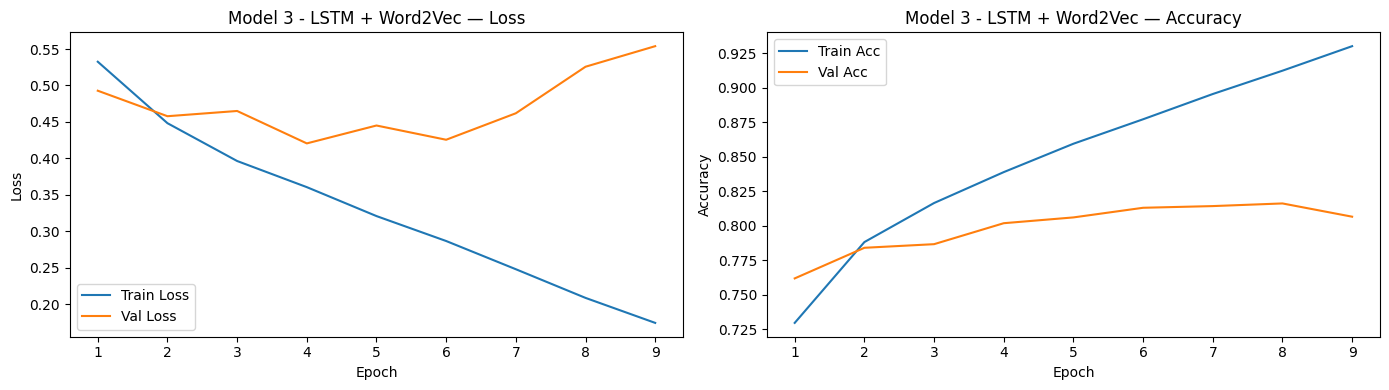

In [ ]:
plot_history(w2v_history, title="Model 3 - LSTM + Word2Vec")

**Model 3 Evaluation**

Model 3 - LSTM + Word2Vec - Test Accuracy: 0.8017

               precision    recall  f1-score   support

Not Sarcastic       0.80      0.82      0.81      2997
    Sarcastic       0.80      0.78      0.79      2727

     accuracy                           0.80      5724
    macro avg       0.80      0.80      0.80      5724
 weighted avg       0.80      0.80      0.80      5724



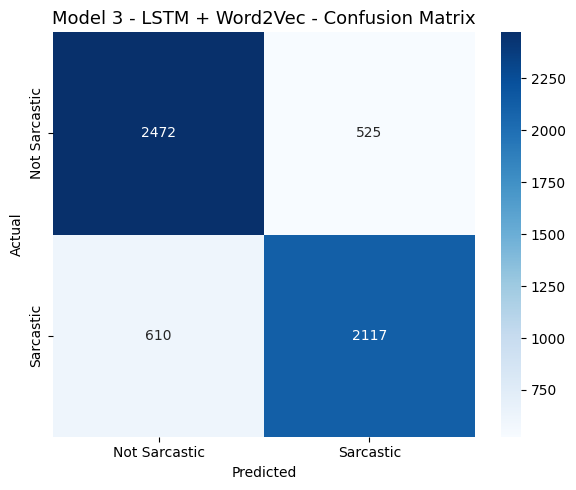

In [ ]:
w2v_labels, w2v_preds = get_all_preds(w2v_model_clf, test_loader, device)
w2v_acc = accuracy_score(w2v_labels, w2v_preds)

print(f"Model 3 - LSTM + Word2Vec - Test Accuracy: {w2v_acc:.4f}")
print()
print(
    classification_report(
        w2v_labels, w2v_preds, target_names=["Not Sarcastic", "Sarcastic"]
    )
)
plot_confusion_matrix(
    w2v_labels, w2v_preds, title="Model 3 - LSTM + Word2Vec - Confusion Matrix"
)

## Section 3: Comparative Analysis

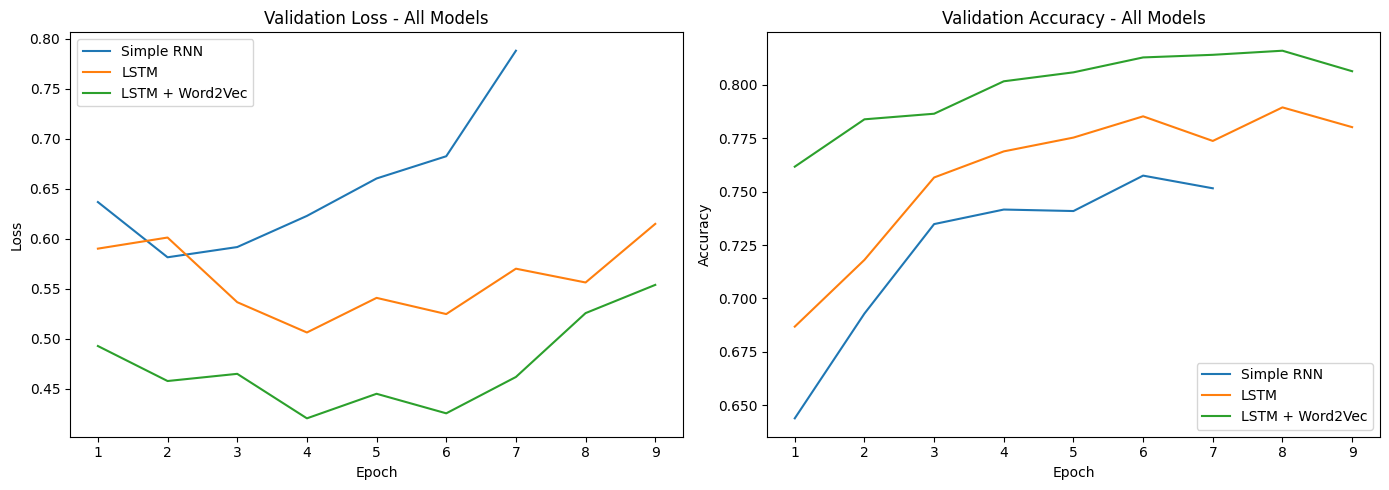

In [ ]:
# Side-by-side loss curves for all three models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for hist, label in [
    (rnn_history, "Simple RNN"),
    (lstm_history, "LSTM"),
    (w2v_history, "LSTM + Word2Vec"),
]:
    e = range(1, len(hist["val_loss"]) + 1)
    axes[0].plot(e, hist["val_loss"], label=label)
    axes[1].plot(e, hist["val_acc"], label=label)

axes[0].set_title("Validation Loss - All Models")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[1].set_title("Validation Accuracy - All Models")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
print(f"{'Model':<30}{'Test Acc':<12}{'Train Time (s)':<18}")
print("-" * 60)
print(f"{'Simple RNN':<30}{rnn_acc:<12.4f}{rnn_time:<18.1f}")
print(f"{'LSTM':<30}{lstm_acc:<12.4f}{lstm_time:<18.1f}")
print(f"{'LSTM + Word2Vec':<30}{w2v_acc:<12.4f}{w2v_time:<18.1f}")

Model                         Test Acc    Train Time (s)    
------------------------------------------------------------
Simple RNN                    0.6929      62.9              
LSTM                          0.7689      250.2             
LSTM + Word2Vec               0.8017      200.8             


## Section 4: Error Analysis

In [ ]:
# Using the best model (LSTM + Word2Vec) for error analysis
# Finding misclassified examples by matching predictions back to original headlines

test_indices = np.where(
    np.isin(
        np.arange(len(df)),
        train_test_split(
            np.arange(len(df)), test_size=0.2, random_state=42, stratify=y
        )[1],
    )
)[0]

# Collect misclassified samples
misclassified = []
for i, (true, pred) in enumerate(zip(w2v_labels, w2v_preds)):
    if true != pred:
        orig_idx = test_indices[i]
        misclassified.append(
            {
                "headline": df["headline"].iloc[orig_idx],
                "true_label": true,
                "predicted": pred,
            }
        )

print(f"Total misclassified: {len(misclassified)} / {len(w2v_labels)}")
print()

Total misclassified: 1135 / 5724



In [ ]:
# Display 3 misclassified examples
for i, sample in enumerate(misclassified[:3]):
    label_map = {0: "Not Sarcastic", 1: "Sarcastic"}
    print(f"Example {i + 1}")
    print(f"Headline: {sample['headline']}")
    print(f"True Label: {label_map[sample['true_label']]}")
    print(f"Predicted: {label_map[sample['predicted']]}")
    print()

Example 1
Headline: eat your veggies: 9 deliciously different recipes
True Label: Not Sarcastic
Predicted: Sarcastic

Example 2
Headline: shadow government getting too large to meet in marriott conference room b
True Label: Sarcastic
Predicted: Not Sarcastic

Example 3
Headline: this lesbian is considered a father in indiana (and an amazing one at that)
True Label: Sarcastic
Predicted: Not Sarcastic



In [ ]:
# False Positive vs False Negative breakdown
fp = sum(
    1 for t, p in zip(w2v_labels, w2v_preds) if t == 0 and p == 1
)  # predicted sarcastic, actually not
fn = sum(
    1 for t, p in zip(w2v_labels, w2v_preds) if t == 1 and p == 0
)  # predicted not sarcastic, actually is

print(f"False Positives (predicted Sarcastic, actually Not): {fp}")
print(f"False Negatives (predicted Not Sarcastic, actually Sarcastic): {fn}")

False Positives (predicted Sarcastic, actually Not): 525
False Negatives (predicted Not Sarcastic, actually Sarcastic): 610


In [ ]:
import pickle
import torch

torch.save(lstm_model.state_dict(), "best_model.pth")

with open("vocab.pkl", "wb") as f:
    pickle.dump(vocab, f)

with open("config.pkl", "wb") as f:
    pickle.dump({"max_len": max_len}, f)

print("Saved: best_model.pth, vocab.pkl, config.pkl")